Analyze time-series fluorescence data from PURE (Protein synthesis Using Recombinant Elements) experiments. 

## Setup 

In [4]:
%load_ext autoreload
%autoreload 2
    
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Import the cdk platereader module
# from cdk.analysis.cytosol import platereader as pr
import platereader as pr

# Set up plotting
pr.plot_setup()

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Load Data

In [3]:
# Specify file paths
data_file = "../data/MN.08.12_raw.txt"
platemap_file = "../data/platemap-mod.csv"


# Load data
data, platemap = pr.load_platereader_data(
    data_file=data_file,
    platemap_file=platemap_file,
    platereader="cytations"  # Options: "cytations", "envision", "biotek-cdk"
)
# Checkout first few rows
data.head()

,Well,Row,Column,Time,Seconds,Temperature (C),Read,Data,Date,Experiment,Name,Type
0,B9,B,9,0 days 00:00:00,0.00,36.90,"GFP/mScarlett:485,520",10.00,NaN,laczsensor,Unregulated,Sample
1,B9,B,9,0 days 00:05:00,300.00,37.00,"GFP/mScarlett:485,520",10.00,NaN,laczsensor,Unregulated,Sample
2,B9,B,9,0 days 00:10:00,600.00,37.00,"GFP/mScarlett:485,520",109.00,NaN,laczsensor,Unregulated,Sample
3,B9,B,9,0 days 00:15:00,900.00,37.00,"GFP/mScarlett:485,520",576.00,NaN,laczsensor,Unregulated,Sample
4,B9,B,9,0 days 00:20:00,1200.00,37.00,"GFP/mScarlett:485,520",1522.00,NaN,laczsensor,Unregulated,Sample


## Plot Raw Curves

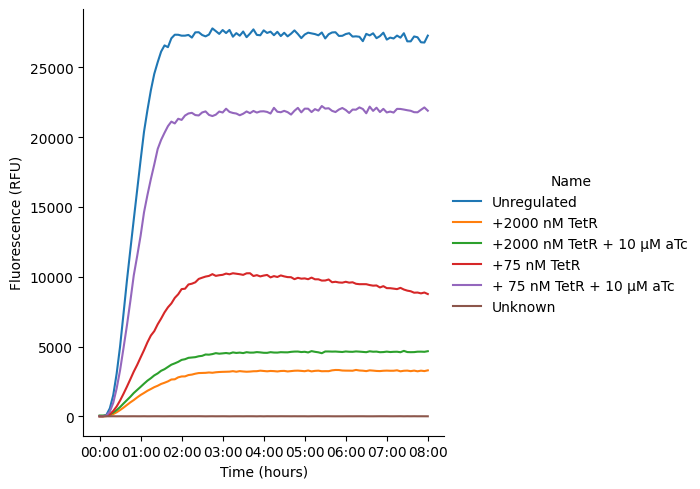

In [3]:
g = pr.plot_curves(data=data)

## Normalize Data

In [4]:
# data = pr.normalize_data_to_controls(data, ctrl_name = '10 uM HPTS') #Nothing to normalize in this data with unfortunately

Now replot your curves to see them normalized

In [5]:
# g = pr.plot_curves(data=data)

## Kinetic Analysis
**Metrics extracted:**

  - **Vmax** (`Velocity Max`): Maximum rate of fluorescence increase (slope at inflection point)
  - **Lag time**: Time to reach the exponential phase
  - **Steady-state**: Final fluorescence level and time to reach 95% of asymptote
  - **Drift**: Rate of signal decay or increase after steady-state
  - **R²**: Goodness of fit

In [6]:
# Perform kinetic analysis using sigmoid_drift model
kinetics = pr.kinetic_analysis(
    data=data,
    group_by=['Name'],  # Group by experimental condition
)

kinetics.head()

Calculating Kinetics


Velocity                    \
                                                    Time     Data      Max   
Name                      Well                                               
Unregulated               B9   0 days 00:50:16.597745952 13859.40 30891.31   
+2000 nM TetR             B10  0 days 01:00:42.084471063  1665.44  2072.37   
+2000 nM TetR + 10 µM aTc B11  0 days 01:01:27.344586054  2352.95  2851.84   
+75 nM TetR               B12  0 days 01:12:37.459079719  5536.60  6997.83   
+ 75 nM TetR + 10 µM aTc  B13  0 days 00:52:23.804355190 11073.45 21874.56   

                                                     Lag          \
                                                    Time    Data   
Name                      Well                                     
Unregulated               B9   0 days 00:23:21.456207798 3273.64   
+2000 nM TetR             B10  0 days 00:12:28.974217003  162.82   
+2000 nM TetR + 10 µM aTc B11  0 days 00:11:57.114961501  254.25   
+75 nM TetR               B12  0 days 00:25:09.179636880 1211.32   
+ 75 nM TetR + 10 µM aTc  B13  0 days 00:22:01.395322096 1912.79   

                                            Steady State           \
                                                    Time     Data   
Name                      Well                                      
Unregulated               B9   0 days 01:29:54.440595456 26332.86   
+2000 nM TetR             B10  0 days 02:11:41.377772515  3164.34   
+2000 nM TetR + 10 µM aTc B11  0 days 02:14:20.174527777  4470.60   
+75 nM TetR               B12  0 days 02:22:30.751586191 10519.55   
+ 75 nM TetR + 10 µM aTc  B13  0 days 01:37:06.790451422 21039.55   

                                                                              Fit  \
                                                                           params   
Name                      Well                                                      
Unregulated               B9    [27718.795641707457, 4.457813655432441, 0.8379...   
+2000 nM TetR             B10   [3330.88803688575, 2.4886711420865244, 1.01169...   
+2000 nM TetR + 10 µM aTc B11   [4705.893753578395, 2.4240550092880433, 1.0242...   
+75 nM TetR               B12   [11073.209301034507, 2.5278418590273763, 1.210...   
+ 75 nM TetR + 10 µM aTc  B13   [22146.8910280702, 3.95081448237468, 0.8732789...   

                                                      
                                R^2   drift good_fit  
Name                      Well                        
Unregulated               B9   1.00  -78.39     True  
+2000 nM TetR             B10  1.00   30.06     True  
+2000 nM TetR + 10 µM aTc B11  1.00   39.32     True  
+75 nM TetR               B12  0.99 -259.16     True  
+ 75 nM TetR + 10 µM aTc  B13  1.00   95.27     True

## Visualize Fits on Individual Wells

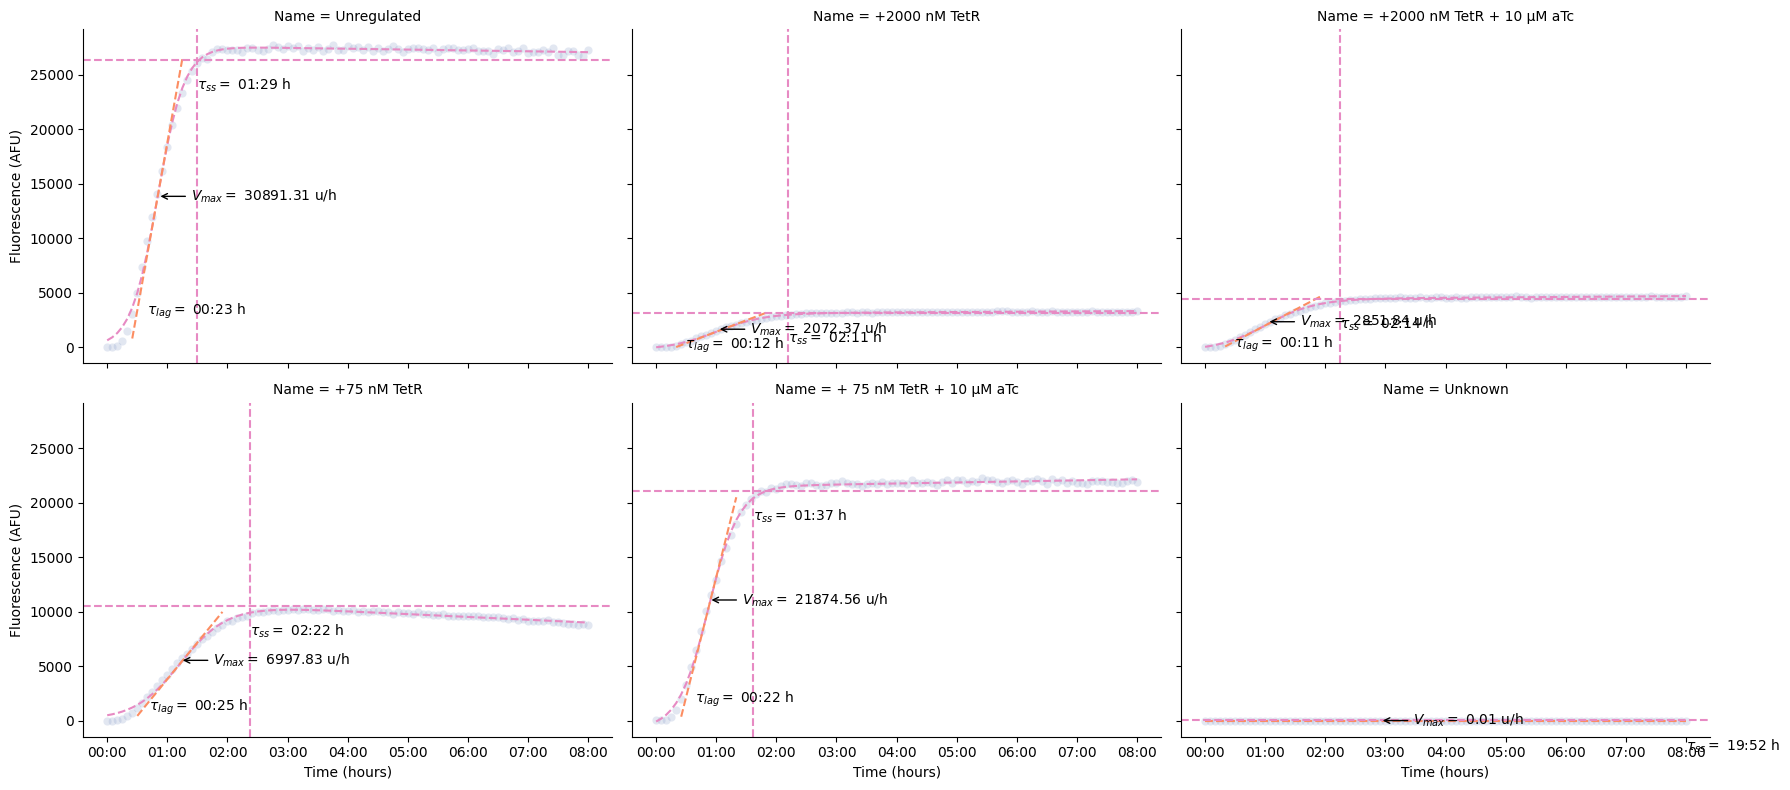

In [7]:
# Plot kinetic fits 
g = pr.plot_kinetics(data, kinetics=kinetics, group_by=["Name"])

In [8]:
pr.kinetic_analysis_summary(data)

Calculating Kinetics


## Summary Plots

Calculating Kinetics


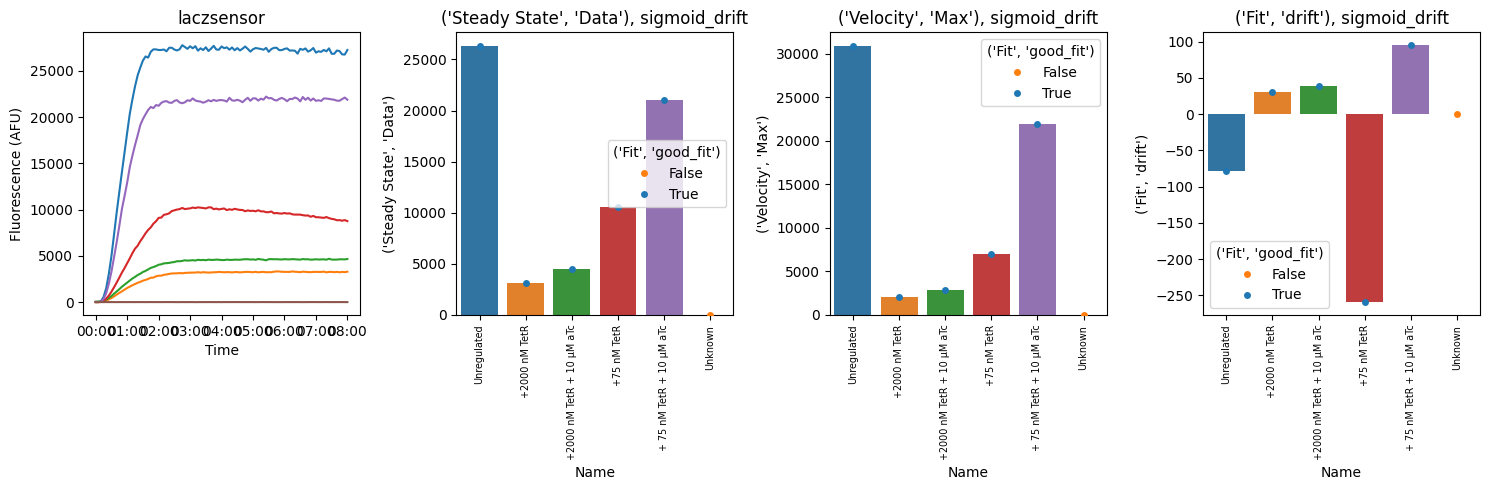

In [10]:
_ = pr.plot_summary(data)

---

## Key Metrics Explained

### 1. **Steady-State Level** (`Steady State, Data`)
- The final fluorescence value reached by the reaction
- Represents the total amount of protein produced
- Higher values indicate greater expression yield

### 2. **Maximum Velocity** (`Velocity, Max`)
- The steepest slope of the fluorescence curve (at the inflection point)
- Units: RFU per second
- Reflects the peak rate of protein synthesis
- Sensitive to enzyme activity, substrate availability, and reaction conditions

### 3. **Lag Time** (`Lag, Time`)
- Time before exponential fluorescence increase begins
- May reflect time for ribosome assembly or initial translation steps
- Shorter lag times suggest faster reaction initiation

### 4. **Drift** (`Fit, drift`)
- Rate of fluorescence change after reaching steady-state
- Positive drift: continued synthesis or aggregation
- Negative drift: photobleaching, protein degradation, or quenching
- Units: RFU per second

### 5. **R² Value** (`Fit, R^2`)
- Goodness of fit (0 to 1, higher is better)
- R² > 0.98 indicates excellent fit
- Poor fits may indicate noisy data, overflow errors, or non-sigmoid kinetics

---

## Tips and Troubleshooting

- **Overflow errors:** Wells with `OVRFLW` or `NaN` values are automatically excluded from fitting
- **Poor fits (low R²):** Inspect raw curves for anomalies (bubbles, evaporation, pipetting errors)
- **Drift:** Sometimes seen in kinetics curves; use `sigmoid_drift` model
- **Multiple replicates:** Always include technical replicates and report error bars
- **Comparing conditions:** Normalize or blank data consistently across all samples

---

## Next Steps

- Export kinetics results: `pr.export_kinetics(kinetics, 'results.csv')`
- Statistical analysis: Use `scipy.stats` or `statsmodels` for ANOVA/t-tests
- Parameter optimization: Vary Mg²⁺, K⁺, or other conditions to maximize Vmax or steady-state
- Mechanistic modeling: Fit ODE models to extract biological rate constants